Text and binary


### File Handling.

Writing data to a file

Reading data from a file

Updating data inside a file

Deleting a file

In [ ]:
name = "Lohit"

In [1]:
with open("data.text", "w") as f:
  f.append("Lohit")

AttributeError: '_io.TextIOWrapper' object has no attribute 'append'

When a python program runs all data (variabel, list, text, etc) lives in RAM. When the program end, that data disabpperar forever.

File hadling solves this problem.


In [ ]:
## Text Files(.txt)   (.ipynb, .py)

# Plain text files that store human-readable characters.
# Each line end with newline character(\n). can be opened in any text editor

In [ ]:
### Opening Files = open()

In [ ]:
# Open(file, mode)

# Mode 'r': Opens a file for reading only.

In [ ]:
file_path = "/content/data.text"

In [ ]:
## 'r' - Read mode

# file must exist, other wise you get FileNotFoundError

with open("notes.txt", 'r') as f:
  content = f.read()
  print(content)
  print

FileNotFoundError: [Errno 2] No such file or directory: 'notes.txt'

In [ ]:
with open("/content/data.text", 'r') as f:
  content = f.read()
  print(content)
  print(type(content))

Lohit
<class 'str'>


In [ ]:
# safe version with error handling:

try:
    with open("notes.txt", 'r') as f:
      print(f.read())
except FileNotFoundError:
  print("File does not exist!")


File does not exist!


In [ ]:
try:
    with open("data.text", 'r') as f:
      print(f.read())
except FileNotFoundError:
  print("File does not exist!")

Lohit


## Mode "w" - write(overwrite)

Opens a file for writing. If file does not exist, Python create it. If it does exist, all previous content is ERASED and replaced. Be carefull!!

In [2]:
## First wriet some intital content

with open("scores.txt", 'w') as f:
  f.write("Alice: 95\n")
  f.write("Bob: 87\n")

In [ ]:
with open("scores.txt", "w") as f:
  f.write("Charlie: 92\n")

## 'a' - Append Mode

Opens a file for writing but move the cursor to the END of the existing content. New data is data after old data. Existing content is never erased. Creates the file if it doesn't exist.

In [3]:
# 'a' mode = APPEND (adds to the end,  never deletes)

# day 1 attendance
with open('attendance.txt', 'a') as f:
  f.write("Day 1: Alice, Bob, Charlie\n")

In [4]:
# day 2;


with open("attendance.txt", 'a') as f:
  f.write("Day 2: Alice, Diana, Eve\n")

In [5]:
# day 3;

with open("attendance.txt", 'a') as f:
  f.write("Day 3: Bob, Charlie, Eve\n")

### Key difference between 'a' and 'w';

'w' -> Cursor at start- Erase old data

'a' -> Cursor at END -> keeps old data

### 'x' Create mode (safe)

Create a new file and opens it for writing. Raise FileExistsError if the file already exist. Use this when you want to make sure you never accidently overwrite a file..

In [ ]:
try:
  with open("new_report.txt", 'x') as f:
    f.write("This is a brand new file!\n")
  print("File created succesfully!")
except FileExistsError:
  print("Error: File already exists. Not overwriting.")

File created succesfully!


In [ ]:
try:
  with open("new_report.txt", 'x') as f:
    f.write("This is a brand new file!\n")
  print("File created succesfully!")
except FileExistsError:
  print("Error: File already exists. Not overwriting.")

Error: File already exists. Not overwriting.


## x vs w

w - Create OR overwrites (dangerour if file exist)

x - create only if new (safe, never overwrites)

case 1:

write = if file already exist (overwrite)
if file does not exists it'll create one


create(x) = if file already exist(FileExistError) there is no chance of overwriting existing file.
- if file does not exists itll create one.

In [ ]:
(No text file)

txt  = Normal human readable textfile

binary  = image, videos , audio (0's, 1's)


## Mode 'rb' and 'wb'

'rb'(Read Binary):
Opens a file for reading in binary mode. Returns bytes objects instead of string. Used for images, audio videos, and other non -text file.


'wb' (write Binary):
Opens a file for writing in binary mode. writes bytes objects. Used to save binary data like images or downloads.  



In [9]:
## Reading a binary data

with open("random_image.jpg", 'rb') as f:
  data = f.read()
  print(type(data))
  print('Size: ', len(data), "bytes")
  print("Frist 4 bytes:", data[:4])

<class 'bytes'>
Size:  14013 bytes
Frist 4 bytes: b'\xff\xd8\xff\xe0'


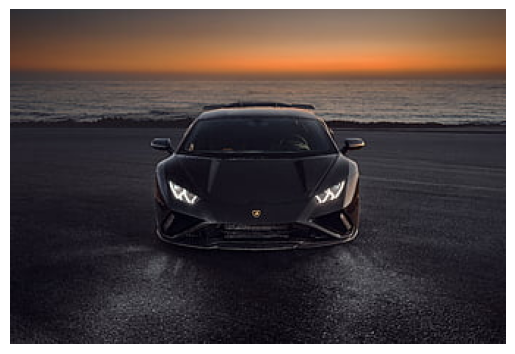

In [40]:
from PIL import Image
import matplotlib.pyplot as plt

with open("random_image.jpg", "rb") as f:
    img = Image.open(f)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [10]:
# copying a binary file
with open("random_image.jpg", "rb") as src:
  with open("photo_copy.jpg", "wb") as dst:
    dst.write(src.read())

| Mode  | Creates File?              | Overwrites?              | Read? | Write? | Cursor Starts At |
|-------|----------------------------|--------------------------|-------|--------|------------------|
| "r"   | No (error if missing)      | No                       | Yes   | No     | Beginning        |
| "w"   | Yes                        | Yes                      | No    | Yes    | Beginning        |
| "a"   | Yes                        | No                       | No    | Yes    | End              |
| "x"   | Yes (only if not exists)   | No (error if exists)     | No    | Yes    | Beginning        |
| "rb"  | No (error if missing)      | No                       | Yes   | No     | Beginning        |
| "wb"  | Yes                        | Yes                      | No    | Yes    | Beginning        |
| "ab"  | Yes                        | No                       | No    | Yes    | End              |

### Reading Files - Modes

f.read():
Reads the entire file content and returns it as a single string.
After calling read(). the cursor is at the end of the file.


f.read(n):
Reads and returns only n characters from the current cursor position.

In [11]:
with open('poem.txt', 'w') as f:
    f.write('Roses are red,\n')
    f.write('Violets are blue,\n')
    f.write('Python is great,\n')
    f.write('And so are you!\n')

In [12]:
with open('poem.txt', 'r') as f:
  everything = f.read()
  print(everything)

Roses are red,
Violets are blue,
Python is great,
And so are you!



In [17]:
with open('poem.txt', 'r') as f:
  first6 = f.read(6)
  print(first6)

  next5 = f.read(5)
  print(next5)

  next_10 = f.read(10)
  print(next_10)

Roses 
are r
ed,
Violet


readline() - Read one line from the file including the \n character at the end. Each call reads the NEXT line. Retrun empty string "" when end of file is reached.

In [52]:
with open('poem.txt', 'r') as f:
  line1 = f.readline()
  line2 = f.readline()
  line3 = f.readline()
  line4 = f.readline()
  line5 = f.readline()

  print(line1)
  print(repr(line2))
  print(repr(line3))
  print(line5)


Roses are red,

'Violets are blue,\n'
'Python is great,\n'



## readlines() - All lines into a list.

Reads all lines at once and retursn a Python list where each eleemt is one line (including the \n character)

In [26]:
with open('poem.txt', 'r') as f:
  lines = f.readlines()

In [27]:
lines

['Roses are red,\n',
 'Violets are blue,\n',
 'Python is great,\n',
 'And so are you!\n']

In [28]:
type(lines)

list

In [32]:
# Accessing specific lines by index

print('First line:', lines[0])

First line: Roses are red,



In [33]:
print("Last line", lines[-1])

Last line And so are you!



In [37]:
# sort lines alphabetically

sorted_lines = sorted(lines)
print(sorted_lines)
print()

for line in sorted_lines:
  print(line)

['And so are you!\n', 'Python is great,\n', 'Roses are red,\n', 'Violets are blue,\n']

And so are you!

Python is great,

Roses are red,

Violets are blue,



In [38]:
lines

['Roses are red,\n',
 'Violets are blue,\n',
 'Python is great,\n',
 'And so are you!\n']

In [39]:
len(lines[0])

15

In [ ]:
/content/photo_copy.jpg

### Writing to files..

write()-

writes the given string to the file.

IMPORTANT: Does NOT add a newline (\n) automatically. - you must add it yourself.

In [46]:
with open("shopping.txt", 'w') as f:
  f.write("Apples\n")
  f.write("Bananas\n")
  f.write("Oranges\n")


In [47]:
with open('test.txt', 'w') as f:
  f.write("hello")
  f.write("world")

## Writelines()

f.writelines(list):
Writes each element of the list to the file one after another.

Does Not add newlines between elements - you must include \n in each string

In [50]:
fruits = ["Apple\n", "Banana\n", "Cherry\n", "Data\n"]

with open('fruits.txt', 'w') as f:
  f.writelines(fruits)

In [51]:
# if you dont add \n in each element itll add it in a same line

fruits = ["Apple", "Banana", "Cherry", "Data"]

with open('fruits_2.txt', 'w') as f:
  f.writelines(fruits)

### Writing Mutiple data types

The write() function only strings. To write number, booles, or lists, you must convert them to string first using str() or f-string

In [53]:
## writing different data types

age = 17
gpa = 3.85
subjects = ["Math", "Science", "Python"]
is_passing = True

with open("Student_info.txt", 'w') as f:

  # method 1: str() conversion
  f.write("age: " + str(age) + "\n")

  # fstring
  f.write(f"GPA: {gpa}\n")
  f.write(f"Passing: {is_passing}\n")